# 📊 TCC — Análise de Sentimento no Mercado Financeiro Brasileiro
## FASE IMG-B3 — Índice de Medo e Ganância (dados reais) — v2

**Autor:** Yago de Azevedo Gomes — MBA em IA e Big Data (ICMC-USP)

Este notebook constrói o **IMG-B3**, um índice composto de medo e ganância para o mercado brasileiro, usando **apenas dados reais e públicos** já coletados na Fase 1 (2020–2024), e conduz a análise empírica do trabalho: relação do índice com retornos e volatilidade futuros do Ibovespa, capacidade preditiva sob protocolo temporal e backtest por perfil de suitability.



### Metodologia (resumo)
Cinco componentes, inspirados no Fear & Greed Index (CNN) e no índice FEARS (Da, Engelberg e Gao, 2015):

| # | Componente | Intuição | Fonte |
|---|-----------|----------|-------|
| 1 | Momentum: Ibovespa vs média móvel de 125 pregões | mercado acima da tendência = apetite a risco | Yahoo Finance |
| 2 | Volatilidade realizada de 30 pregões (invertida) | volatilidade alta = medo | Yahoo Finance |
| 3 | VIX (invertido) | aversão global a risco | Yahoo Finance |
| 4 | Variação de 20 pregões do câmbio BRL/USD (invertida) | dólar subindo = fuga de risco | Yahoo Finance |
| 5 | FEARS-BR: atenção a termos de medo no Google Trends (invertido) | buscas por "crise", "recessão" = medo das famílias | Google Trends |

Cada componente é convertido em **percentil móvel de 252 pregões** (só usa o passado — sem lookahead) e o IMG-B3 é a **média simples** dos cinco percentis, de 0 a 100. Zonas: 0–20 Medo Extremo · 20–40 Medo · 40–60 Neutro · 60–80 Ganância · 80–100 Ganância Extrema.

⚠️ Execute **após** a Fase 1 e a Fase 2 (precisa de `dados_mercado_2020_2024.csv`, `google_trends_diario.csv` e `headlines_classificadas.csv`). GPU não é necessária.

In [ ]:
# — Monta Google Drive e configura pasta do TCC (idêntico às fases anteriores) —
from google.colab import drive
drive.mount('/content/drive')
import os, shutil
PASTA_DRIVE = '/content/drive/MyDrive/TCC_dados'
os.makedirs(PASTA_DRIVE, exist_ok=True)
if os.path.islink('dados_tcc'):
    os.unlink('dados_tcc')
if os.path.exists('dados_tcc') and not os.path.islink('dados_tcc'):
    shutil.rmtree('dados_tcc')
os.symlink(PASTA_DRIVE, 'dados_tcc')
print('✅ Drive montado:', PASTA_DRIVE)
for a in ['dados_tcc/dados_mercado_2020_2024.csv', 'dados_tcc/google_trends_diario.csv', 'dados_tcc/headlines_classificadas.csv']:
    print(('✅' if os.path.exists(a) else '❌'), a)


Mounted at /content/drive
✅ Drive montado: /content/drive/MyDrive/TCC_dados
✅ dados_tcc/dados_mercado_2020_2024.csv
✅ dados_tcc/google_trends_diario.csv
✅ dados_tcc/headlines_classificadas.csv


In [ ]:
!pip install -q pandas numpy scipy statsmodels scikit-learn matplotlib
import pandas as pd, numpy as np, json, warnings
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt, matplotlib.dates as mdates
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25})
print('✅ Importações concluídas')


✅ Importações concluídas


## 🧮 BLOCO 1 — Construção do IMG-B3

In [ ]:
mkt = pd.read_csv('dados_tcc/dados_mercado_2020_2024.csv', index_col=0, parse_dates=True)
tr  = pd.read_csv('dados_tcc/google_trends_diario.csv', index_col=0, parse_dates=True)

# ---------- componentes brutos ----------
c = pd.DataFrame(index=mkt.index)
c['momentum']  = mkt['ibovespa_fechamento'] / mkt['ibovespa_fechamento'].rolling(125, min_periods=21).mean() - 1
c['vol30']     = -mkt['retorno_ibov'].rolling(30, min_periods=10).std()      # invertida: vol alta = medo
c['vix_inv']   = -mkt['vix']                                                  # invertido
c['fx']        = -mkt['cambio_brlusd'].pct_change(20)                         # invertida: dólar subindo = medo
medo_terms = [t for t in ['crise econômica', 'recessão', 'inflação', 'dólar hoje', 'juros'] if t in tr.columns]
print('Termos de medo encontrados no Trends:', medo_terms)
z = pd.DataFrame(index=tr.index)
for t in medo_terms:
    s = tr[t]; mu = s.expanding(30).mean(); sd = s.expanding(30).std()
    z[t] = (s - mu) / sd
c['fears_inv'] = -z.mean(axis=1).reindex(mkt.index).ffill()

# ---------- normalização: percentil móvel de 252 pregões (só passado) ----------
def roll_pct(s, win=252, minp=30):
    a = s.to_numpy(); n = len(a); res = np.full(n, np.nan)
    for i in range(n):
        w = a[max(0, i - win + 1):i + 1]; w = w[~np.isnan(w)]
        if len(w) >= minp and not np.isnan(a[i]):
            res[i] = (w[:-1] <= a[i]).mean() * 100
    return pd.Series(res, index=s.index)

comp_pct = pd.DataFrame({k: roll_pct(c[k]) for k in c.columns})
out = comp_pct.copy()
out['IMG']     = comp_pct.mean(axis=1, skipna=False)
out['IMG_ma7'] = out['IMG'].rolling(7, min_periods=1).mean()
def zona(v):
    if pd.isna(v): return np.nan
    return 'Medo Extremo' if v < 20 else 'Medo' if v < 40 else 'Neutro' if v < 60 else 'Ganância' if v < 80 else 'Ganância Extrema'
out['zona'] = out['IMG'].apply(zona)
out = out.join(mkt[['ibovespa_fechamento', 'retorno_ibov', 'vix', 'cambio_brlusd', 'selic']])
out.to_csv('dados_tcc/IMG_diario.csv')

df = out.dropna(subset=['IMG']).copy()
ORDEM = ['Medo Extremo', 'Medo', 'Neutro', 'Ganância', 'Ganância Extrema']
print(f'\nIMG válido: {len(df)} de {len(out)} pregões | período: {df.index.min().date()} → {df.index.max().date()}')
dist = df['zona'].value_counts().reindex(ORDEM)
print('\n[TABELA — distribuição por zona]')
for zn in ORDEM: print(f'  {zn:<17} {dist[zn]:>5}  ({dist[zn]/len(df)*100:.1f}%)')
print(f'\nIMG: média {df.IMG.mean():.1f} | mín {df.IMG.min():.1f} ({df.IMG.idxmin().date()}) | máx {df.IMG.max():.1f} ({df.IMG.idxmax().date()})')

print('\n[VALIDAÇÃO POR EVENTOS — valor do IMG-B3 no pregão mais próximo]')
EVENTOS = [('2020-03-23', 'Mínima COVID-19'), ('2021-06-07', 'Pico pós-pandemia'), ('2022-02-24', 'Invasão da Ucrânia'),
           ('2022-10-30', 'Eleições (2º turno)'), ('2023-01-12', 'Crise Americanas'), ('2023-12-28', 'Rali de dez/2023'),
           ('2024-07-11', 'Máxima histórica'), ('2024-12-18', 'Stress fiscal dez/2024')]
for d, nome in EVENTOS:
    i = out.index.get_indexer([pd.Timestamp(d)], method='nearest')[0]; r = out.iloc[i]
    if pd.isna(r['IMG']): print(f'  {out.index[i].date()} {nome:<24} IMG indisponível (janela inicial)'); continue
    print(f'  {out.index[i].date()} {nome:<24} IMG = {r["IMG"]:5.1f}  ({r["zona"]})')


Termos de medo encontrados no Trends: ['crise econômica', 'recessão', 'inflação', 'dólar hoje', 'juros']

IMG válido: 1194 de 1243 pregões | período: 2020-03-16 → 2024-12-30

[TABELA — distribuição por zona]
  Medo Extremo         37  (3.1%)
  Medo                209  (17.5%)
  Neutro              421  (35.3%)
  Ganância            435  (36.4%)
  Ganância Extrema     92  (7.7%)

IMG: média 55.3 | mín 0.7 (2024-12-19) | máx 93.2 (2023-07-03)

[VALIDAÇÃO POR EVENTOS — valor do IMG-B3 no pregão mais próximo]
  2020-03-23 Mínima COVID-19          IMG =  12.6  (Medo Extremo)
  2021-06-07 Pico pós-pandemia        IMG =  66.4  (Ganância)
  2022-02-24 Invasão da Ucrânia       IMG =  54.1  (Neutro)
  2022-10-31 Eleições (2º turno)      IMG =  39.2  (Medo)
  2023-01-12 Crise Americanas         IMG =  64.9  (Ganância)
  2023-12-28 Rali de dez/2023         IMG =  89.7  (Ganância Extrema)
  2024-07-11 Máxima histórica         IMG =  72.9  (Ganância)
  2024-12-18 Stress fiscal dez/2024   IMG =   1.3

## 📐 BLOCO 2 — Análise quantitativa com dados reais
- Correlação IMG(d) × retorno acumulado futuro do Ibovespa em 1, 5 e 21 pregões
- Retorno futuro (21 pregões) por zona do índice — teste de Kruskal-Wallis e Mann-Whitney
- Regressão R(d+1) ~ IMG(d) + controles, erros HC3
- IMG(d) × volatilidade realizada dos 21 pregões seguintes
- Ponte com a Fase 2: IMG nos dias das manchetes negativas vs positivas

In [ ]:
R = {}
def fwd_sum(h):   # retorno acumulado de d+1 a d+h
    return df['retorno_ibov'].shift(-1).rolling(h).sum().shift(-(h - 1))

print('[TABELA — correlação IMG(d) × retorno futuro acumulado]')
for h in [1, 5, 21]:
    m = pd.concat([df['IMG'], fwd_sum(h).rename('f')], axis=1).dropna()
    pr, pp = stats.pearsonr(m['IMG'], m['f']); sr, sp = stats.spearmanr(m['IMG'], m['f'])
    R[f'h{h}'] = (pr, pp, sr, sp, len(m))
    print(f'  {h:>2} pregão(ões): Pearson {pr:+.4f} (p={pp:.3f}) | Spearman {sr:+.4f} (p={sp:.3f}) | n={len(m)}')

R['corr_IMG_VIX'] = stats.pearsonr(df['IMG'], df['vix'])[0]
print(f'\nIMG × VIX (contemporâneo): r = {R["corr_IMG_VIX"]:+.3f}')

# retorno futuro 21d por zona
fwd21 = fwd_sum(21)
zz = pd.concat([df['zona'], fwd21.rename('f')], axis=1).dropna()
zres = zz.groupby('zona')['f'].agg(['mean', 'median', 'count']).reindex(ORDEM)
groups = [g.values for _, g in zz.groupby('zona')['f']]
R['kw'] = stats.kruskal(*groups)
a = zz[zz['zona'].isin(['Medo Extremo', 'Medo'])]['f']; b = zz[zz['zona'].isin(['Ganância', 'Ganância Extrema'])]['f']
R['mw'] = (a.mean(), len(a), b.mean(), len(b), stats.mannwhitneyu(a, b).pvalue)
print('\n[TABELA — retorno futuro de 21 pregões por zona]')
print(zres.round(2).to_string())
print(f'  Média geral: {zz.f.mean():+.2f}% | Kruskal-Wallis H = {R["kw"].statistic:.2f}, p = {R["kw"].pvalue:.4f}')
print(f'  Medo (extremo+medo) n={len(a)} média {a.mean():+.2f}%  vs  Ganância (ganância+extrema) n={len(b)} média {b.mean():+.2f}%  | Mann-Whitney p = {R["mw"][4]:.4f}')
zres.round(2).to_csv('dados_tcc/IMG_retorno_por_zona.csv')

# regressão
reg = pd.DataFrame({'ret_fwd1': df['retorno_ibov'].shift(-1), 'IMG': df['IMG'],
                    'delta_cambio': df['cambio_brlusd'].pct_change() * 100, 'vix': df['vix'], 'ret_d': df['retorno_ibov']}).dropna()
X = sm.add_constant(reg[['IMG', 'delta_cambio', 'vix', 'ret_d']])
mod = sm.OLS(reg['ret_fwd1'], X).fit(cov_type='HC3')
open('dados_tcc/regressao_IMG_summary.txt', 'w').write(mod.summary().as_text())
print('\n[TABELA — regressão R(d+1) ~ IMG(d) + ΔCâmbio + VIX + R(d), erros HC3]')
print(f'  R² ajustado = {mod.rsquared_adj:.4f} | F = {mod.fvalue:.3f} (p = {mod.f_pvalue:.4f}) | n = {int(mod.nobs)}')
for v in X.columns: print(f'  {v:<13} coef {mod.params[v]:+.4f} | EP {mod.bse[v]:.4f} | p {mod.pvalues[v]:.4f}')

# volatilidade futura (21 pregões, anualizada)
vol_fut = df['retorno_ibov'].shift(-1).rolling(21).std().shift(-20) * np.sqrt(252)
mv = pd.concat([df['IMG'], vol_fut.rename('vf')], axis=1).dropna()
R['vol'] = stats.pearsonr(mv['IMG'], mv['vf']) + (stats.spearmanr(mv['IMG'], mv['vf'])[0], len(mv))
print(f'\n[IMG × volatilidade dos 21 pregões seguintes] Pearson r = {R["vol"][0]:+.4f} (p = {R["vol"][1]:.2e}) | Spearman {R["vol"][2]:+.4f} | n = {R["vol"][3]}')

# ponte com a Fase 2: IMG nos dias das manchetes
hl = pd.read_csv('dados_tcc/headlines_classificadas.csv', parse_dates=['data'])
hl['IMG'] = [df['IMG'].iloc[df.index.get_indexer([d], method='nearest')[0]] for d in hl['data']]
hl['zona'] = hl['IMG'].apply(zona)
neg, pos = hl[hl['polaridade'] == -1]['IMG'], hl[hl['polaridade'] == 1]['IMG']
R['hl'] = (neg.mean(), len(neg), pos.mean(), len(pos), stats.mannwhitneyu(neg, pos).pvalue)
print(f'\n[Manchetes da Fase 2 × IMG-B3] negativas: n={len(neg)}, IMG médio {neg.mean():.1f} | positivas: n={len(pos)}, IMG médio {pos.mean():.1f} | Mann-Whitney p = {R["hl"][4]:.3f}')
print(hl[['data', 'titulo', 'sentimento', 'IMG', 'zona']].assign(titulo=hl['titulo'].str[:55]).to_string(index=False))
hl.to_csv('dados_tcc/headlines_vs_IMG.csv', index=False)


[TABELA — correlação IMG(d) × retorno futuro acumulado]
   1 pregão(ões): Pearson -0.0032 (p=0.913) | Spearman -0.0117 (p=0.688) | n=1193
   5 pregão(ões): Pearson -0.0124 (p=0.670) | Spearman +0.0266 (p=0.359) | n=1189
  21 pregão(ões): Pearson +0.0018 (p=0.950) | Spearman +0.0455 (p=0.119) | n=1173

IMG × VIX (contemporâneo): r = -0.321

[TABELA — retorno futuro de 21 pregões por zona]
                  mean  median  count
zona                                 
Medo Extremo      4.33    3.03     20
Medo              0.36   -0.28    205
Neutro            1.21    0.89    421
Ganância          1.58    0.99    435
Ganância Extrema -0.32   -0.88     92
  Média geral: +1.13% | Kruskal-Wallis H = 17.71, p = 0.0014
  Medo (extremo+medo) n=225 média +0.71%  vs  Ganância (ganância+extrema) n=527 média +1.25%  | Mann-Whitney p = 0.0210

[TABELA — regressão R(d+1) ~ IMG(d) + ΔCâmbio + VIX + R(d), erros HC3]
  R² ajustado = 0.0045 | F = 0.857 (p = 0.4895) | n = 1192
  const         coef -0.2984 | 

## 🤖 BLOCO 3 — Fase 4 com dados reais: capacidade preditiva sob protocolo temporal
Mesmos três algoritmos da Fase 4, mas com **TimeSeriesSplit** (o treino sempre precede o teste) e as features de sentimento do IMG-B3 — todas conhecidas no fechamento do dia d.

In [ ]:
feat = pd.DataFrame(index=df.index)
feat['retorno_d']    = df['retorno_ibov']
feat['retorno_lag1'] = df['retorno_ibov'].shift(1)
feat['retorno_ma5']  = df['retorno_ibov'].rolling(5).mean()
feat['vol_5d']       = df['retorno_ibov'].rolling(5).std()
feat['vol_20d']      = df['retorno_ibov'].rolling(20).std()
feat['delta_cambio'] = df['cambio_brlusd'].pct_change() * 100
feat['vix']          = df['vix']
SEM = list(feat.columns)
feat['IMG']          = df['IMG']
feat['IMG_ma7']      = df['IMG_ma7']
feat['IMG_delta5']   = df['IMG'].diff(5)
feat['medo_extremo'] = (df['IMG'] < 20).astype(int)
COM = list(feat.columns)
feat['target'] = (df['retorno_ibov'].shift(-1) > 0).astype(int)
feat = feat.dropna().iloc[:-1]
y = feat['target']
tscv = TimeSeriesSplit(n_splits=5)
modelos = {'Regressão Logística': LogisticRegression(max_iter=1000, C=0.5),
           'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42),
           'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, max_depth=2, random_state=42)}
rows = []
for nome, clf in modelos.items():
    for cen, cols in [('Sem sentimento', SEM), ('Com sentimento (IMG)', COM)]:
        f1s, accs = [], []
        for tri, tei in tscv.split(feat):
            pipe = Pipeline([('sc', StandardScaler()), ('m', clf)])
            pipe.fit(feat.iloc[tri][cols], y.iloc[tri]); p = pipe.predict(feat.iloc[tei][cols])
            f1s.append(f1_score(y.iloc[tei], p, average='macro')); accs.append(accuracy_score(y.iloc[tei], p))
        rows.append(dict(Modelo=nome, Cenário=cen, F1=np.mean(f1s), F1_std=np.std(f1s), Acurácia=np.mean(accs)))
res4 = pd.DataFrame(rows)
res4.to_csv('dados_tcc/comparacao_modelos_IMG.csv', index=False)
tab4 = res4.pivot(index='Modelo', columns='Cenário', values='F1')[['Sem sentimento', 'Com sentimento (IMG)']]
tab4['ΔF1'] = tab4['Com sentimento (IMG)'] - tab4['Sem sentimento']
print(f'[TABELA — F1 macro, TimeSeriesSplit k=5, n = {len(feat)}]')
print(res4.round(4).to_string(index=False)); print(); print(tab4.round(4).to_string())


[TABELA — F1 macro, TimeSeriesSplit k=5, n = 1174]
             Modelo              Cenário     F1  F1_std  Acurácia
Regressão Logística       Sem sentimento 0.4918  0.0533    0.5108
Regressão Logística Com sentimento (IMG) 0.4771  0.0291    0.4923
      Random Forest       Sem sentimento 0.4708  0.0517    0.4882
      Random Forest Com sentimento (IMG) 0.4756  0.0565    0.4985
  Gradient Boosting       Sem sentimento 0.4702  0.0355    0.4882
  Gradient Boosting Com sentimento (IMG) 0.4646  0.0250    0.4851

Cenário              Sem sentimento  Com sentimento (IMG)     ΔF1
Modelo                                                           
Gradient Boosting            0.4702                0.4646 -0.0056
Random Forest                0.4708                0.4756  0.0049
Regressão Logística          0.4918                0.4771 -0.0147


## 💼 BLOCO 4 — Backtest por perfil de suitability
Regra (sem lookahead — usa a zona do **pregão anterior**): reduzir a exposição a renda variável em 10 pontos percentuais quando o IMG-B3 está em zona extrema (medo extremo ou ganância extrema). Renda fixa remunerada pela Selic diária. Alocações-base: 10 / 30 / 70 % (Tabela 12 do TCC).

In [ ]:
ret_rv = df['retorno_ibov'] / 100; ret_rf = df['selic'] / 100
zona_prev = df['zona'].shift(1)
adj = {'Medo Extremo': -0.10, 'Medo': 0, 'Neutro': 0, 'Ganância': 0, 'Ganância Extrema': -0.10}
def metricas(r):
    n = len(r); ann = (1 + r).prod() ** (252 / n) - 1; vol = r.std() * np.sqrt(252)
    rf_ann = (1 + ret_rf.loc[r.index]).prod() ** (252 / n) - 1
    cum = (1 + r).cumprod(); dd = (cum / cum.cummax() - 1).min()
    return round(ann * 100, 2), round(vol * 100, 2), round((ann - rf_ann) / vol, 3), round(dd * 100, 2)
BASE = {'Conservador': 0.10, 'Moderado': 0.30, 'Arrojado': 0.70}
rows, curvas = [], {}
for p, w0 in BASE.items():
    r_est = (w0 * ret_rv + (1 - w0) * ret_rf).dropna()
    w = (w0 + zona_prev.map(adj)).clip(0, 1).fillna(w0)
    r_din = (w * ret_rv + (1 - w) * ret_rf).dropna()
    rows.append([p, 'Estática', *metricas(r_est)]); rows.append([p, 'Dinâmica (IMG)', *metricas(r_din)])
    curvas[p] = (r_est, r_din)
bt = pd.DataFrame(rows, columns=['Perfil', 'Estratégia', 'Retorno a.a. (%)', 'Vol a.a. (%)', 'Sharpe', 'Max DD (%)'])
bt.to_csv('dados_tcc/backtest_perfis_IMG.csv', index=False)
ibov_aa = ((1 + ret_rv).prod() ** (252 / len(ret_rv)) - 1) * 100; cdi_aa = ((1 + ret_rf).prod() ** (252 / len(ret_rf)) - 1) * 100
print(f'[TABELA — backtest 2020–2024] Ibovespa {ibov_aa:.2f}% a.a. | Selic {cdi_aa:.2f}% a.a. | dias em zona extrema: {int(zona_prev.isin(["Medo Extremo","Ganância Extrema"]).sum())}')
print(bt.to_string(index=False))


[TABELA — backtest 2020–2024] Ibovespa 8.23% a.a. | Selic 8.85% a.a. | dias em zona extrema: 128
     Perfil     Estratégia  Retorno a.a. (%)  Vol a.a. (%)  Sharpe  Max DD (%)
Conservador       Estática              9.04          2.28   0.085       -1.47
Conservador Dinâmica (IMG)              8.83          2.07  -0.009       -1.14
   Moderado       Estática              9.26          6.82   0.061       -5.64
   Moderado Dinâmica (IMG)              9.07          6.48   0.034       -5.66
   Arrojado       Estática              9.02         15.93   0.011      -16.80
   Arrojado Dinâmica (IMG)              8.86         15.55   0.001      -16.90


## 🖼️ BLOCO 5 — Figuras (salvas em TCC_dados com os nomes usados no TCC)

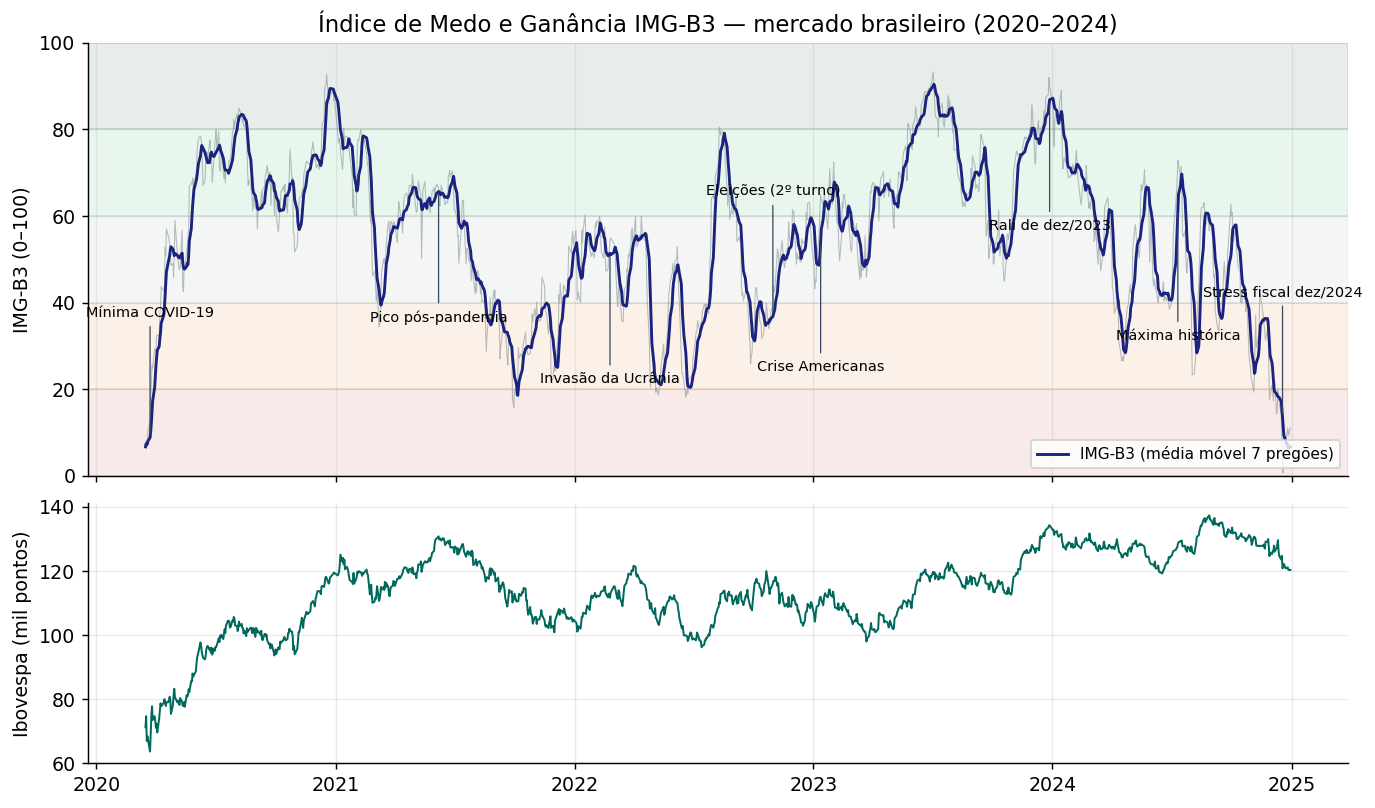

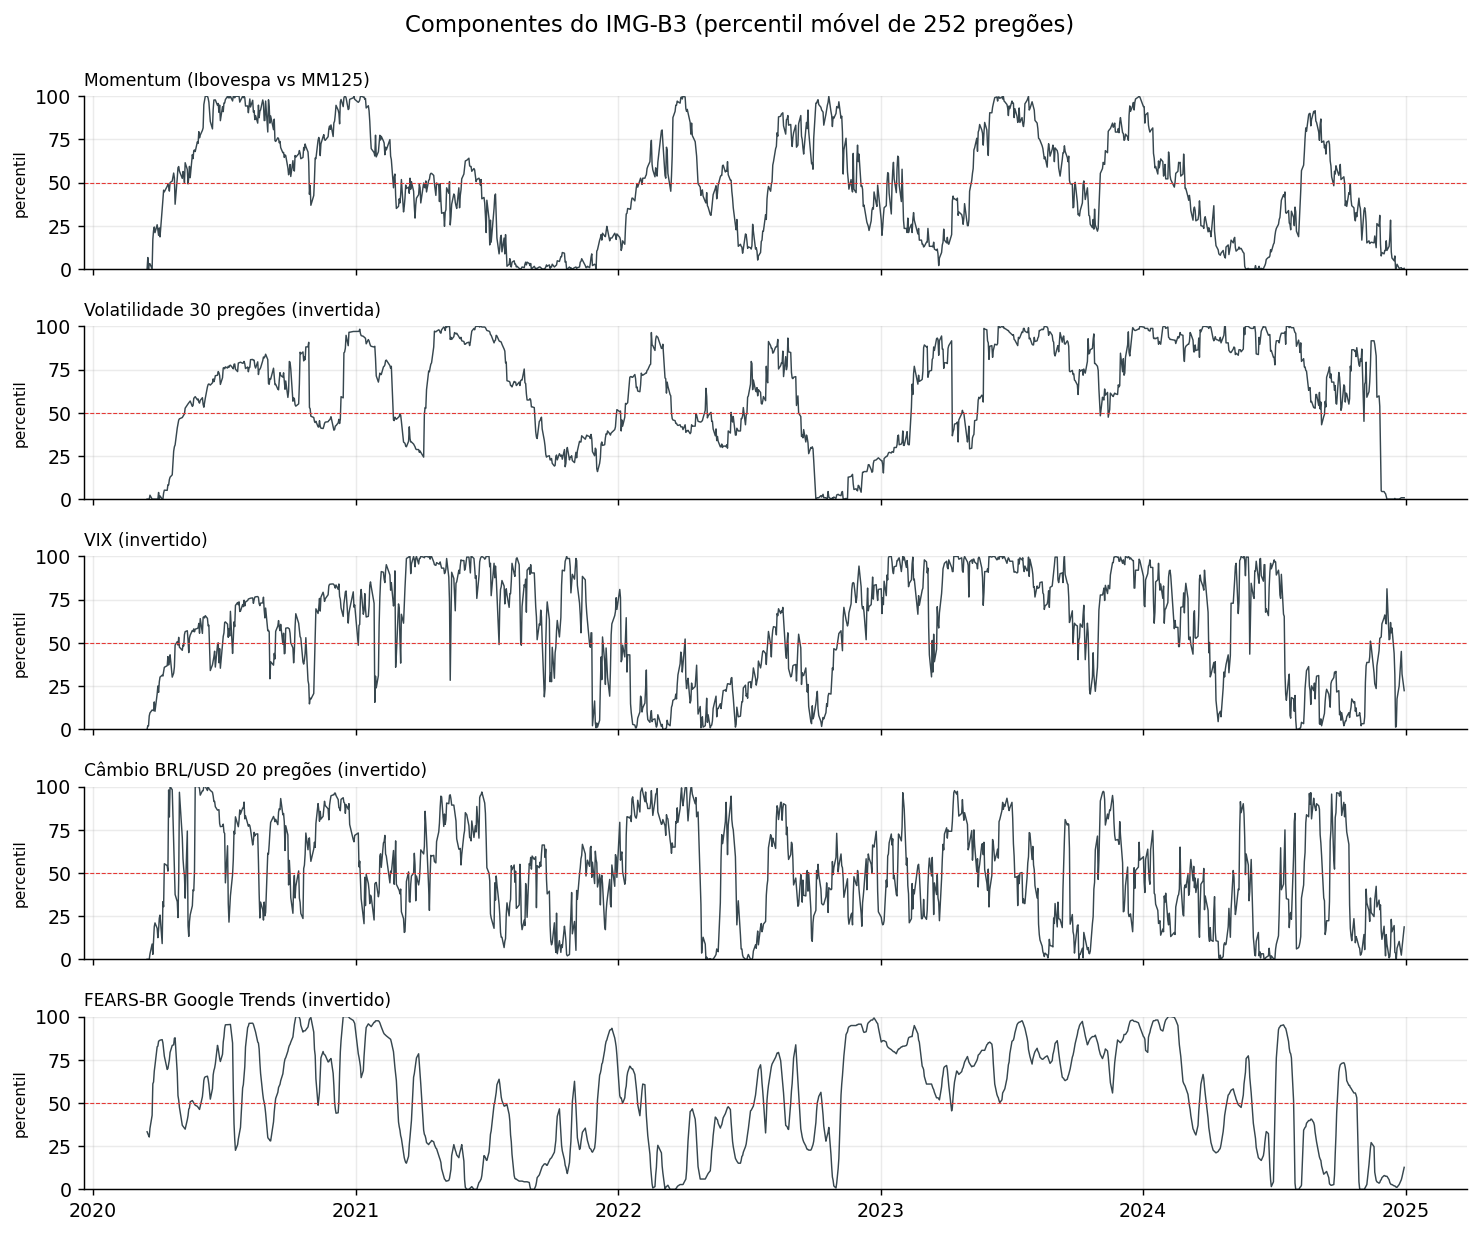

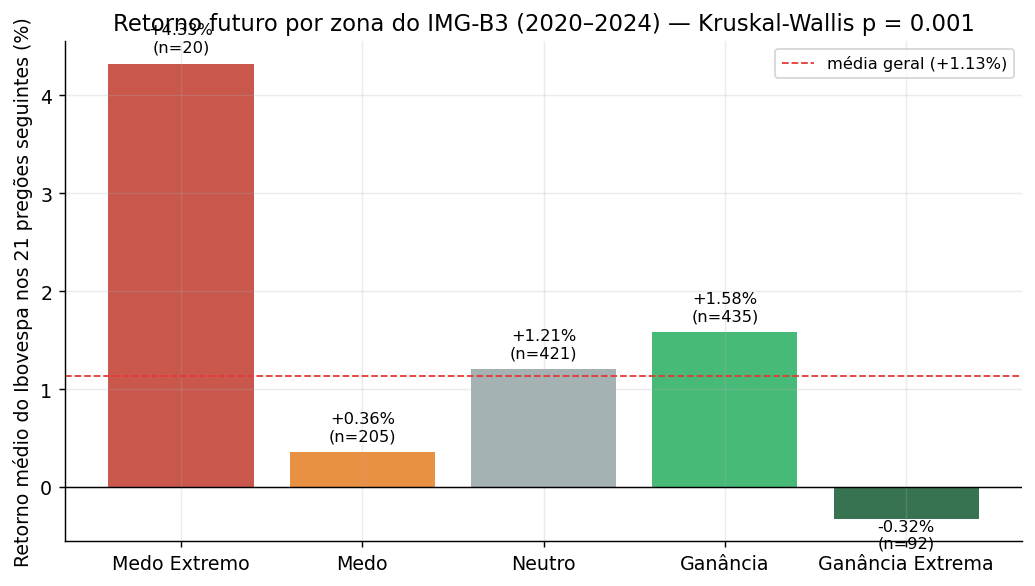

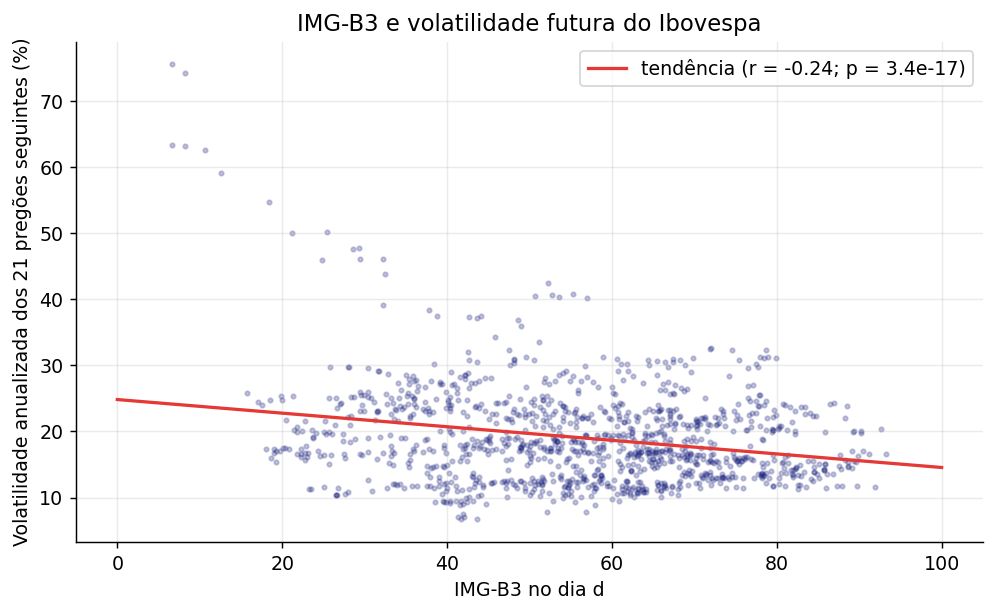

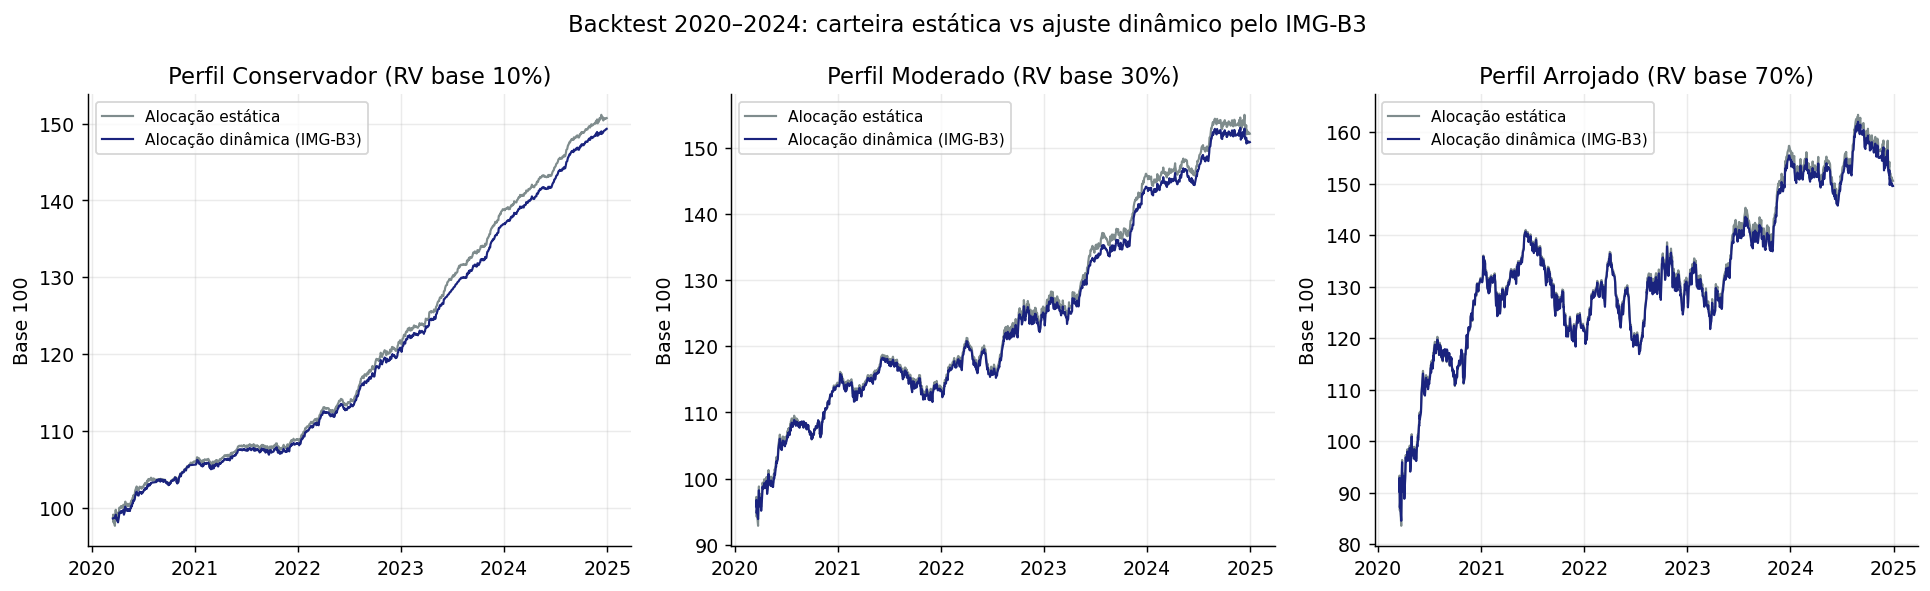

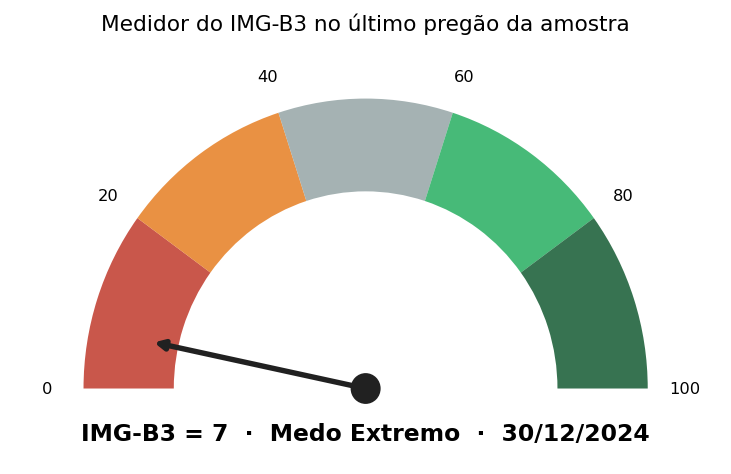

✅ Figuras 15–20 salvas em TCC_dados/


In [ ]:
CORES_ZONA = [('Medo Extremo', 0, 20, '#c0392b'), ('Medo', 20, 40, '#e67e22'), ('Neutro', 40, 60, '#95a5a6'),
              ('Ganância', 60, 80, '#27ae60'), ('Ganância Extrema', 80, 100, '#145a32')]

# fig15 — série do IMG com zonas e eventos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12.5, 7.2), sharex=True, gridspec_kw={'height_ratios': [2, 1.2], 'hspace': 0.08})
for nome, lo, hi, cor in CORES_ZONA: ax1.axhspan(lo, hi, color=cor, alpha=0.10)
ax1.plot(df.index, df['IMG'], color='#7f8c8d', lw=0.6, alpha=0.55)
ax1.plot(df.index, df['IMG_ma7'], color='#1a237e', lw=1.6, label='IMG-B3 (média móvel 7 pregões)')
for d, nome in EVENTOS:
    i = df.index.get_indexer([pd.Timestamp(d)], method='nearest')[0]; v = df['IMG_ma7'].iloc[i]
    ax1.annotate(nome, xy=(df.index[i], v), xytext=(df.index[i], min(97, max(5, v + (28 if v < 50 else -30)))), fontsize=8, ha='center',
                 arrowprops=dict(arrowstyle='-', color='#34495e', lw=0.7))
ax1.set_ylabel('IMG-B3 (0–100)'); ax1.set_ylim(0, 100); ax1.legend(loc='lower right', fontsize=8.5)
ax1.set_title('Índice de Medo e Ganância IMG-B3 — mercado brasileiro (2020–2024)')
ax2.plot(df.index, df['ibovespa_fechamento'] / 1000, color='#00695c', lw=1.1); ax2.set_ylabel('Ibovespa (mil pontos)')
ax2.xaxis.set_major_locator(mdates.YearLocator()); ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.savefig('dados_tcc/fig15_IMG_serie.png', dpi=150, bbox_inches='tight'); plt.show()

# fig16 — componentes
nomes = {'momentum': 'Momentum (Ibovespa vs MM125)', 'vol30': 'Volatilidade 30 pregões (invertida)', 'vix_inv': 'VIX (invertido)',
         'fx': 'Câmbio BRL/USD 20 pregões (invertido)', 'fears_inv': 'FEARS-BR Google Trends (invertido)'}
fig, axes = plt.subplots(5, 1, figsize=(11.5, 9.5), sharex=True)
for ax, (col, nome) in zip(axes, nomes.items()):
    ax.plot(df.index, df[col], lw=0.8, color='#37474f'); ax.axhline(50, color='#e53935', lw=0.6, ls='--')
    ax.set_ylabel('percentil', fontsize=8.5); ax.set_ylim(0, 100); ax.set_title(nome, fontsize=9.5, loc='left')
axes[-1].xaxis.set_major_locator(mdates.YearLocator()); axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Componentes do IMG-B3 (percentil móvel de 252 pregões)', y=0.995); plt.tight_layout()
plt.savefig('dados_tcc/fig16_IMG_componentes.png', dpi=150, bbox_inches='tight'); plt.show()

# fig17 — retorno futuro por zona
fig, ax = plt.subplots(figsize=(9.5, 5))
bars = ax.bar(ORDEM, zres['mean'].values, color=[c[3] for c in CORES_ZONA], alpha=0.85)
for b_, v, n in zip(bars, zres['mean'].values, zres['count'].values):
    ax.text(b_.get_x() + b_.get_width() / 2, v + (0.12 if v >= 0 else -0.3), f'{v:+.2f}%\n(n={int(n)})', ha='center', fontsize=9)
ax.axhline(0, color='k', lw=0.8); ax.axhline(zz.f.mean(), color='#e53935', lw=1, ls='--', label=f'média geral ({zz.f.mean():+.2f}%)')
ax.set_ylabel('Retorno médio do Ibovespa nos 21 pregões seguintes (%)')
ax.set_title(f'Retorno futuro por zona do IMG-B3 (2020–2024) — Kruskal-Wallis p = {R["kw"].pvalue:.3f}'); ax.legend(fontsize=9)
plt.savefig('dados_tcc/fig17_IMG_retorno_por_zona.png', dpi=150, bbox_inches='tight'); plt.show()

# fig18 — IMG × volatilidade futura
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(mv['IMG'], mv['vf'], s=6, alpha=0.25, color='#1a237e')
b1, b0 = np.polyfit(mv['IMG'], mv['vf'], 1); xs = np.linspace(0, 100, 50)
ax.plot(xs, b0 + b1 * xs, color='#e53935', lw=1.8, label=f'tendência (r = {R["vol"][0]:.2f}; p = {R["vol"][1]:.1e})')
ax.set_xlabel('IMG-B3 no dia d'); ax.set_ylabel('Volatilidade anualizada dos 21 pregões seguintes (%)')
ax.set_title('IMG-B3 e volatilidade futura do Ibovespa'); ax.legend()
plt.savefig('dados_tcc/fig18_IMG_volatilidade.png', dpi=150, bbox_inches='tight'); plt.show()

# fig19 — backtest
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (p, (r_est, r_din)) in zip(axes, curvas.items()):
    ax.plot((1 + r_est).cumprod() * 100, label='Alocação estática', color='#7f8c8d', lw=1.2)
    ax.plot((1 + r_din).cumprod() * 100, label='Alocação dinâmica (IMG-B3)', color='#1a237e', lw=1.2)
    ax.set_title(f'Perfil {p} (RV base {BASE[p]*100:.0f}%)'); ax.legend(fontsize=8.5); ax.set_ylabel('Base 100')
    ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Backtest 2020–2024: carteira estática vs ajuste dinâmico pelo IMG-B3'); plt.tight_layout()
plt.savefig('dados_tcc/fig19_IMG_backtest.png', dpi=150, bbox_inches='tight'); plt.show()

# fig20 — medidor
from matplotlib.patches import Wedge, Circle
val = float(df['IMG_ma7'].iloc[-1]); data_ref = df.index[-1].strftime('%d/%m/%Y')
fig, ax = plt.subplots(figsize=(7, 4.2)); ax.axis('off'); ax.set_xlim(-1.25, 1.25); ax.set_ylim(-0.25, 1.2)
for nome, lo, hi, cor in CORES_ZONA:
    ax.add_patch(Wedge((0, 0), 1.0, 180 - hi * 1.8, 180 - lo * 1.8, width=0.32, facecolor=cor, alpha=0.85))
ang = np.radians(180 - val * 1.8)
ax.annotate('', xy=(0.78 * np.cos(ang), 0.78 * np.sin(ang)), xytext=(0, 0), arrowprops=dict(arrowstyle='-|>', lw=3, color='#212121'))
ax.add_patch(Circle((0, 0), 0.05, color='#212121'))
for v in [0, 20, 40, 60, 80, 100]:
    a_ = np.radians(180 - v * 1.8); ax.text(1.13 * np.cos(a_), 1.13 * np.sin(a_), str(v), ha='center', va='center', fontsize=9)
ax.text(0, -0.18, f'IMG-B3 = {val:.0f}  ·  {zona(val)}  ·  {data_ref}', ha='center', fontsize=13, weight='bold')
ax.set_title('Medidor do IMG-B3 no último pregão da amostra', fontsize=12)
plt.savefig('dados_tcc/fig20_IMG_medidor.png', dpi=150, bbox_inches='tight'); plt.show()
print('✅ Figuras 15–20 salvas em TCC_dados/')


## 📋 BLOCO 6 — Números para colar no TCC (seção 4.5)

In [ ]:
print('#' * 72); print(' NÚMEROS PARA O TCC — seção 4.5 (IMG-B3)'); print('#' * 72)
print(f'\n[4.5.1] IMG calculado para {len(df)} pregões ({df.index.min().date()} a {df.index.max().date()})')
print('  Distribuição por zona:'); [print(f'    {zn:<17} {dist[zn]:>4} ({dist[zn]/len(df)*100:.1f}%)') for zn in ORDEM]
print(f'  IMG × VIX: r = {R["corr_IMG_VIX"]:+.2f}')
print('  Eventos:');
for d, nome in EVENTOS:
    i = out.index.get_indexer([pd.Timestamp(d)], method='nearest')[0]; r = out.iloc[i]
    print(f'    {out.index[i].date()} {nome:<24} IMG = {r["IMG"]:5.1f} ({r["zona"]})' if not pd.isna(r['IMG']) else f'    {nome}: indisponível')
print('\n[TABELA 16 — correlação IMG × retorno futuro]')
for h in [1, 5, 21]: pr, pp, sr, sp, n = R[f'h{h}']; print(f'  {h:>2}d: Pearson {pr:+.3f} (p={pp:.3f}) | Spearman {sr:+.3f} (p={sp:.3f}) | n={n}')
print(f'  Regressão defasada: R² aj {mod.rsquared_adj:.4f} | IMG coef {mod.params["IMG"]:+.4f} p={mod.pvalues["IMG"]:.3f}')
print('\n[TABELA 17 — retorno futuro 21d por zona]'); print(zres.round(2).to_string())
print(f'  Kruskal-Wallis H = {R["kw"].statistic:.2f}, p = {R["kw"].pvalue:.4f} | Mann-Whitney medo vs ganância p = {R["mw"][4]:.4f}')
print(f'\n[4.5.3] IMG × volatilidade 21d: r = {R["vol"][0]:+.3f} (p = {R["vol"][1]:.1e}), n = {R["vol"][3]}')
print(f'[4.5.3] Manchetes: negativas IMG médio {R["hl"][0]:.1f} (n={R["hl"][1]}) vs positivas {R["hl"][2]:.1f} (n={R["hl"][3]}), p = {R["hl"][4]:.3f}')
print('\n[TABELA 18 — F1 TimeSeriesSplit]'); print(res4.round(3).to_string(index=False))
print('\n[TABELA 19 — backtest]'); print(bt.to_string(index=False)); print(f'  Ibovespa {ibov_aa:.2f}% a.a. | Selic {cdi_aa:.2f}% a.a.')
print('\nArquivos: IMG_diario.csv, IMG_retorno_por_zona.csv, regressao_IMG_summary.txt, headlines_vs_IMG.csv, comparacao_modelos_IMG.csv, backtest_perfis_IMG.csv, fig15–fig20')


########################################################################
 NÚMEROS PARA O TCC — seção 4.5 (IMG-B3)
########################################################################

[4.5.1] IMG calculado para 1194 pregões (2020-03-16 a 2024-12-30)
  Distribuição por zona:
    Medo Extremo        37 (3.1%)
    Medo               209 (17.5%)
    Neutro             421 (35.3%)
    Ganância           435 (36.4%)
    Ganância Extrema    92 (7.7%)
  IMG × VIX: r = -0.32
  Eventos:
    2020-03-23 Mínima COVID-19          IMG =  12.6 (Medo Extremo)
    2021-06-07 Pico pós-pandemia        IMG =  66.4 (Ganância)
    2022-02-24 Invasão da Ucrânia       IMG =  54.1 (Neutro)
    2022-10-31 Eleições (2º turno)      IMG =  39.2 (Medo)
    2023-01-12 Crise Americanas         IMG =  64.9 (Ganância)
    2023-12-28 Rali de dez/2023         IMG =  89.7 (Ganância Extrema)
    2024-07-11 Máxima histórica         IMG =  72.9 (Ganância)
    2024-12-18 Stress fiscal dez/2024   IMG =   1.3 (Medo Extremo)
